# Day 10 — Cross-Validation & Model Selection

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Rebuild the titanic data
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

df['Age']=df['Age'].fillna(df['Age'].median())
df=df.drop(columns=['Cabin'])
df['Embarked']=df['Embarked'].fillna(df['Embarked'].mode()[0])

df['Sex_encoded'] = df['Sex'].map({'male':0, 'female':1})
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone'] = df.apply(lambda row:1 if(row['SibSp'] + row['Parch'])==0 else 0, axis=1)

df['Title']= df['Name'].str.split(', ').str[1].str.split('.').str[0]
common_titles = ['Mr', 'Mrs', 'Miss','Master']
df['TitleGroup'] = df['Title'].apply(lambda x: x if x in common_titles else 'Other')
df['Title_encoded'] = df['TitleGroup'].map({'Mr':0, 'Mrs':1, 'Miss':2, 'Master':3, 'Other':4})

x= df[['Pclass', 'Sex_encoded', 'Age', 'Fare', 'IsAlone', 'FamilySize', 'Title_encoded']]
y= df['Survived']

## Part 1 — The Problem with One Train/Test Split

In [3]:
# Accuracy varies by 2-4% just from different splits
# Which one is the "real" accuracy? None of them alone.
# This is the problem cross-validation solves.

for seed in [0,1,42,99,123]:
    x_train, x_test, y_train, y_test = train_test_split(
        x, y, test_size=0.2, random_state=seed)

    lr = LogisticRegression(max_iter=1000)
    lr.fit(x_train, y_train)
    acc = accuracy_score(y_test, lr.predict(x_test))
    print(f'Seed {seed}: {acc:.2%}')

Seed 0: 77.09%
Seed 1: 79.33%
Seed 42: 79.89%
Seed 99: 77.65%
Seed 123: 81.56%


## Part 2 — K-Fold Cross-Validation

In [4]:
#Instead of one split, use 5 different splits and average the results
lr = LogisticRegression(max_iter=1000)

#cross_val_score does all of this automatically:
# split data into 5 folds
# Train on 4 folds, test on 1
# Repeat 5 times, each fold gets to be the test set once
# Returns all 5 scores
scores = cross_val_score(lr, x, y, cv=5, scoring='accuracy')

In [5]:
print(f'Individual fold scores: {scores}')
print(f'Mean accuracy: {scores.mean():.2%}')
print(f'Standard deviation: {scores.std():.2%}')

#Standard deviation tells how stable the model is
#Low std = consistent, High std= unreliable

Individual fold scores: [0.79888268 0.80337079 0.78651685 0.80898876 0.80337079]
Mean accuracy: 80.02%
Standard deviation: 0.76%


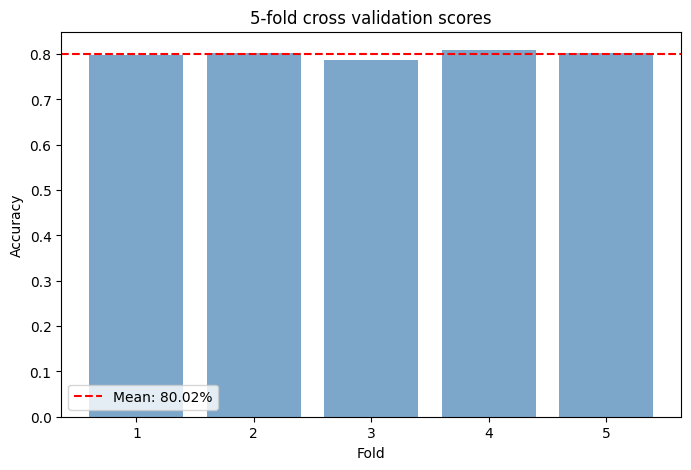

In [6]:
#Visualise the fold scores
fig, ax = plt.subplots(figsize=(8,5))
ax.bar(range(1,6), scores, color='steelblue', alpha=0.7)
ax.axhline(scores.mean(), color='red', linestyle='--', label=f'Mean: {scores.mean():.2%}')

ax.set_xlabel('Fold')
ax.set_ylabel('Accuracy')
ax.set_title('5-fold cross validation scores')
ax.legend()
plt.show()

## Part 4 — Scaling & Pipelines

In [7]:
# KNN and Logistic Regression are sensitive to feature scale
# Age ranges 0-80, Fare ranges 0-500 - Fare dominates unfairly
print(x.describe())

           Pclass  Sex_encoded         Age        Fare     IsAlone  \
count  891.000000   891.000000  891.000000  891.000000  891.000000   
mean     2.308642     0.352413   29.361582   32.204208    0.602694   
std      0.836071     0.477990   13.019697   49.693429    0.489615   
min      1.000000     0.000000    0.420000    0.000000    0.000000   
25%      2.000000     0.000000   22.000000    7.910400    0.000000   
50%      3.000000     0.000000   28.000000   14.454200    1.000000   
75%      3.000000     1.000000   35.000000   31.000000    1.000000   
max      3.000000     1.000000   80.000000  512.329200    1.000000   

       FamilySize  Title_encoded  
count  891.000000     891.000000  
mean     1.904602       0.804714  
std      1.613459       1.095455  
min      1.000000       0.000000  
25%      1.000000       0.000000  
50%      1.000000       0.000000  
75%      2.000000       2.000000  
max     11.000000       4.000000  


In [8]:
# StandardScaler fix this - transforms each feature to mean=0, std=1
scaler=StandardScaler()
x_scaled=scaler.fit_transform(x)

In [11]:
#But there's a problem with doing it this way manually...
#If we scale before splitting, test data influences the scaler
#This is called data leakage - it inflates the results
#The fix is a pipeline - it scales INSIDE the cross-validation loop

#Pipeline chains steps together safely
pipeline_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000))
])

pipeline_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('model', KNeighborsClassifier(n_neighbors=5))
])

In [13]:
#Now compare with and without scaling
for name, model in [('LR no scaling', LogisticRegression(max_iter=1000)),
                    ('LR with scaling', pipeline_lr),
                    ('KNN no scaling', KNeighborsClassifier(n_neighbors=5)),
                    ('KNN with scaling', pipeline_knn)]:
    scores=cross_val_score(model, x, y, cv=5, scoring='accuracy')
    print(f"{name}: {scores.mean():.2%} (+/- {scores.std():.2%})")

#KNN should improve noticeably with scaling
#Logistic Regression imporves slightly

LR no scaling: 80.02% (+/- 0.76%)
LR with scaling: 80.02% (+/- 0.76%)
KNN no scaling: 72.28% (+/- 3.07%)
KNN with scaling: 83.16% (+/- 3.43%)


## Part 5 — Exercises

In [17]:
# Exercise 1
# Use cross_val_score with scoring='roc_auc' instead of 'accuracy'
# Compare all 3 models by AUC using cross-validation
# Which model has the best AUC? Is it the same as best accuracy?

for name, model in [('LR', LogisticRegression(max_iter=1000)),
                    ('KNN', KNeighborsClassifier(n_neighbors=5)),
                    ('DT', DecisionTreeClassifier(random_state=42))]:
    scores= cross_val_score(model, x, y, cv=5, scoring='roc_auc')
    print(f"{name}: {scores.mean():.2%} (+/- {scores.std():.2%})")

LR: 85.45% (+/- 1.70%)
KNN: 74.80% (+/- 4.11%)
DT: 76.49% (+/- 4.47%)


In [19]:
# Exercise 2
# Try cv=10 (10-fold) instead of cv=5 for Logistic Regression
# Compare mean and std dev with cv=5
# More folds = more reliable but slower. Is the difference meaningful here?
model = LogisticRegression(max_iter=1000)
cv5scores=cross_val_score(model, x, y, cv=5, scoring='accuracy')
print(f"CV5: {cv5scores.mean():.2%} (+/- {cv5scores.std():.2%})")

cv10scores=cross_val_score(model, x, y, cv=10, scoring='accuracy')
print(f"CV10: {cv10scores.mean():.2%} (+/- {cv10scores.std():.2%})")

#I couldn't notice any meaningful difference.

CV5: 80.02% (+/- 0.76%)
CV10: 80.59% (+/- 2.92%)


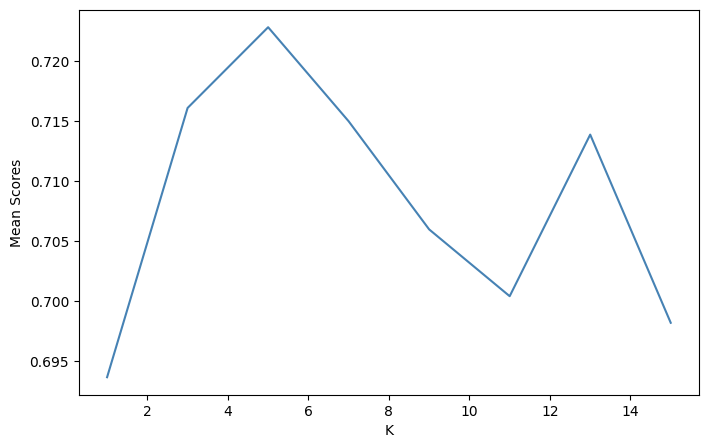

Optimal K:  5


In [29]:
# Exercise 3
# Find the optimal k for KNN using cross-validation
# Try k = 1, 3, 5, 7, 9, 11, 13, 15
# Use cross_val_score for each k value
# Plot mean accuracy vs k
# This is cleaner than Day 9's approach because CV is more reliable than one split

k_values = [1,3,5,7,9,11,13,15]
mean_scores = []

for i in k_values:
    model = KNeighborsClassifier(n_neighbors=i)
    scores = cross_val_score(model, x, y, cv=5, scoring='accuracy')
    mean_scores.append(scores.mean())

fig, ax = plt.subplots(figsize=(8,5))
ax.plot(k_values, mean_scores, color='steelblue')
ax.set_xlabel('K')
ax.set_ylabel('Mean Scores')
plt.show()


best_score = max(mean_scores)
best_idx = mean_scores.index(best_score)
best_k = k_values[best_idx]

print("Optimal K: ",best_k)


In [ ]:
# Exercise 4 (stretch)
# Build a final Pipeline with the best model you found
# Include StandardScaler + best model
# Run 5-fold CV and print mean AUC and mean accuracy
# Save the pipeline — you'll deploy this on Day 11
# import joblib
# joblib.dump(pipeline, 'titanic_model.pkl')

#Failed to do by myself

In [31]:
#Ans of ex4: there are exactly 3 steps. Memorise this...

#-------- Step 1 - Build Pipeline ---------
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

#Chain scaler + model together
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000))
])


#-------- Step 2 - Verify works with CV ---------
from sklearn.model_selection import cross_val_score

scores_acc = cross_val_score(pipeline, x, y, cv=5, scoring='accuracy')
scores_auc = cross_val_score(pipeline, x, y, cv=5, scoring='roc_auc')

print(f"Mean Accuracy: {scores_acc.mean():.2%} (+/- {scores_acc.std():.2%})")
print(f"Mean AUC:      {scores_auc.mean():.2f} (+/- {scores_auc.std():.2f})")


#-------- Step 3 - Train on All data and save ---------
import joblib

# IMPORTANT: fit on All data before saving, not just x_train
# CV already told us how well it performs - now we use every sample
pipeline.fit(x,y)

#Save to disk
joblib.dump(pipeline, 'titanic_model.pkl')
print("Model saved.")

#Verify it can be loaded later
loaded_model = joblib.load('titanic_model.pkl')
test_passenger = pd.DataFrame([{'Pclass': 3, 'Sex_encoded': 0, 'Age':22, 'Fare': 7.25, 'IsAlone':1,
                               'FamilySize': 1, 'Title_encoded':0}])

prob = loaded_model.predict_proba(test_passenger)[0][1]
print(f"Test prediction: {prob:.2%} chance of surviving")

Mean Accuracy: 80.02% (+/- 0.76%)
Mean AUC:      0.85 (+/- 0.02)
Model saved.
Test prediction: 10.51% chance of surviving


#### Every time you need to save and deploy a model, need to do this, just remember:
1. Pipeline([('scaler', Scaler()), ('model', Model())])
2. cross_val_score to verify performance
3. pipeline.fit(ALL data) then joblib.dump to save
4. joblib.load to verify it works